# Kinase T5 hierarchy

In [32]:
from katlas.clustering import *
from katlas.data import *
from katlas.feature import *
from katlas.plot import *

import pandas as pd, numpy as np

In [28]:
info=Data.get_kinase_info()

In [29]:
info.shape

(523, 36)

In [30]:
info.columns

Index(['kinase', 'ID_coral', 'uniprot', 'gene', 'modi_group', 'group',
       'family', 'subfamily_coral', 'subfamily', 'in_pspa_st', 'in_pspa_tyr',
       'in_pspa', 'in_cddm', 'kd_ID', 'active_D1_D2', 'active_kd_ID',
       'pspa_ID', 'pseudo', 'pspa_category_small', 'pspa_category_big',
       'cddm_big', 'cddm_small', 'length', 'human_uniprot_sequence',
       'kinasecom_domain', 'nucleus', 'cytosol', 'cytoskeleton',
       'plasma membrane', 'mitochondrion', 'Golgi apparatus',
       'endoplasmic reticulum', 'vesicle', 'centrosome', 'aggresome',
       'main_location'],
      dtype='object')

In [36]:
info=info[info.human_uniprot_sequence.str.len()<5000]

In [37]:
info = info[~info.kinase.str.contains('_b|_2')].reset_index(drop=True)

In [38]:
info[info.human_uniprot_sequence.duplicated(keep=False)]

,kinase,ID_coral,uniprot,gene,modi_group,group,family,subfamily_coral,subfamily,in_pspa_st,...,cytosol,cytoskeleton,plasma membrane,mitochondrion,Golgi apparatus,endoplasmic reticulum,vesicle,centrosome,aggresome,main_location


In [39]:
info.shape

(507, 36)

## T5 embeddings

In [43]:
feature = get_t5(info,'human_uniprot_sequence')

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


  0%|          | 0/507 [00:00<?, ?it/s]

In [47]:
feature.index=info.kinase

In [50]:
feature

/home/sky1ove/git/katlas/.venv/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/home/sky1ove/git/katlas/.venv/lib/python3.11/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,T5_0,T5_1,T5_2,T5_3,T5_4,T5_5,T5_6,T5_7,T5_8,T5_9,...,T5_1014,T5_1015,T5_1016,T5_1017,T5_1018,T5_1019,T5_1020,T5_1021,T5_1022,T5_1023
kinase,,,,,,,,,,,,,,,,,,,,,
AAK1,0.056274,0.066528,0.077576,0.010185,-0.030762,0.044861,-0.051788,-0.030167,0.010437,-0.007874,...,-0.041718,-0.077393,-0.023361,0.012962,0.071716,0.008446,-0.071045,0.019363,-0.003197,-0.012413
AATK,-0.001738,-0.028183,0.055511,-0.012909,-0.004894,0.032166,-0.033936,-0.048676,0.076843,0.034058,...,-0.000751,-0.036194,-0.026352,-0.017014,0.009399,0.035736,0.017212,-0.013489,0.022949,0.079773
ABL1,0.009750,0.011368,0.031204,-0.000709,0.005157,0.050629,-0.024017,-0.036987,0.051483,-0.007980,...,-0.014618,-0.024673,-0.048248,-0.004753,0.032166,0.025558,0.004871,0.044006,0.001851,0.019043
ABL2,0.008217,0.000241,0.022705,0.001262,-0.000204,0.052795,-0.032806,-0.038849,0.049347,-0.011520,...,-0.002037,-0.031036,-0.051117,-0.022949,0.030548,0.041412,0.009804,0.040649,0.008743,0.020920
ACVR1C,0.034943,0.098511,0.053558,0.030258,-0.021255,0.037415,-0.036346,-0.066162,0.010223,0.014893,...,-0.046600,-0.028793,-0.036743,-0.018906,0.032532,-0.008156,-0.035187,-0.028793,-0.036469,-0.001018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YES1,0.034882,0.097534,0.042877,0.006760,-0.010063,0.031708,-0.026627,-0.045990,-0.003342,-0.009605,...,-0.005806,-0.012741,-0.073730,-0.015350,0.057709,-0.006027,-0.010864,0.000340,-0.019440,-0.009087
YSK1,0.049072,0.081970,0.022079,0.004959,0.005402,0.022247,-0.024216,-0.041168,-0.027023,-0.015083,...,-0.042480,-0.012794,-0.062805,0.015465,0.053314,-0.032227,-0.030594,-0.006836,-0.013931,-0.002098
YSK4,0.020233,0.008957,-0.014725,0.008110,-0.047638,0.103333,-0.125122,-0.036072,0.096313,0.116821,...,-0.030411,0.026611,-0.003803,-0.117493,0.024155,0.078491,-0.027466,-0.031097,0.033295,0.031281


In [7]:
feature.to_parquet('raw/kinome_t5.parquet')

## Feature

In [8]:
feature = pd.read_parquet('raw/kinome_t5.parquet')

In [14]:
def euclidean_flat(a, b):
    """Compute Euclidean distance between two flattened arrays."""
    # a = np.ravel(a)
    # b = np.ravel(b)
    return np.linalg.norm(a - b)

In [15]:
Z = get_Z(feature,func_flat=euclidean_flat)

  0%|          | 0/128271 [00:00<?, ?it/s]

In [17]:
labels=feature.index

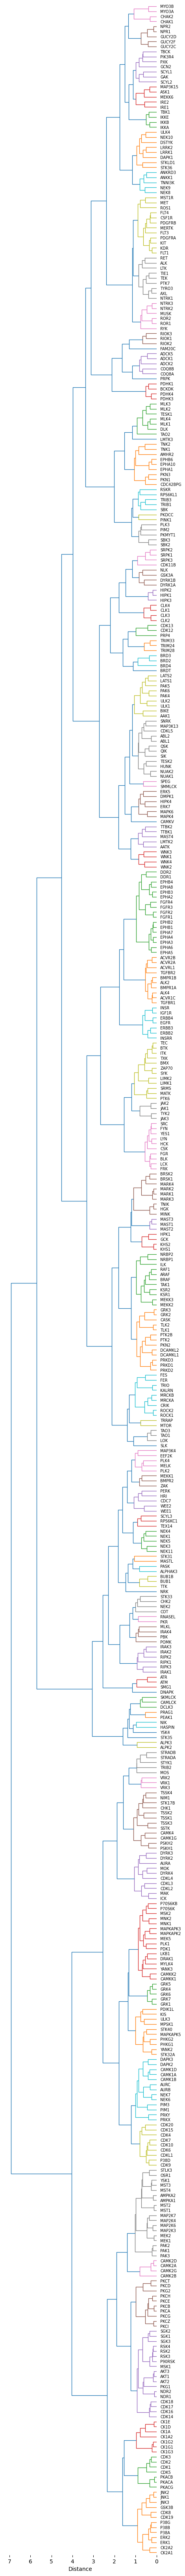

In [34]:
plot_dendrogram(Z,dense=6,labels=labels,color_thr=1.1)
save_svg('raw/kinase_hierarchy.svg')